In [1]:
import os
from pathlib import Path

# Set working directory

WORKDIR = Path("/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_3_full_h5ad.reprocess.sep10.dataset")
if not WORKDIR.exists():
    raise FileNotFoundError(f"Workdir not found: {WORKDIR}")
os.chdir(WORKDIR)
print("📁 Working dir:", WORKDIR)
print("📄 Files:", ", ".join(sorted(p.name for p in WORKDIR.iterdir())))
print("Files:", os.listdir('.'))

📁 Working dir: /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_3_full_h5ad.reprocess.sep10.dataset
📄 Files: hypoxia_all_samples_tokens.dataset, hypoxia_proportional_3000_per_condition.dataset, original_per_condition, proportional_subsampling_barplots.png, proportional_subsampling_comparison.csv, proportional_subsampling_differences.png, proportional_subsampling_side_by_side.png
Files: ['proportional_subsampling_differences.png', 'proportional_subsampling_barplots.png', 'proportional_subsampling_side_by_side.png', 'hypoxia_proportional_3000_per_condition.dataset', 'proportional_subsampling_comparison.csv', 'hypoxia_all_samples_tokens.dataset', 'original_per_condition']


In [2]:
import os, sys, gc, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import torch

from datasets import load_from_disk, Dataset, DatasetDict, concatenate_datasets

# --- Warnings & GC ---
warnings.filterwarnings("ignore", category=FutureWarning)
torch.cuda.empty_cache()
gc.collect();

# --- Runtime / GPU info ---
print(f"🐍 Python: {sys.executable}")
print(f"🧠 PyTorch: {torch.__version__}")
cuda_ok = torch.cuda.is_available()
print(f"⚙️  CUDA available: {cuda_ok}")

if cuda_ok:
    dev = torch.cuda.current_device()
    name = torch.cuda.get_device_name(dev)
    alloc_gb = torch.cuda.memory_allocated() / (1024**3)
    reserv_gb = torch.cuda.memory_reserved() / (1024**3)
    print(f"🖥️  GPU[{dev}]: {name}")
    print(f"   • mem allocated: {alloc_gb:.2f} GB | reserved: {reserv_gb:.2f} GB")
    torch.cuda.empty_cache()
    gc.collect()
    alloc_gb = torch.cuda.memory_allocated() / (1024**3)
    reserv_gb = torch.cuda.memory_reserved() / (1024**3)
    print(f"   • after empty_cache → allocated: {alloc_gb:.2f} GB | reserved: {reserv_gb:.2f} GB")

# --- Optional: echo intended conda env (note: this does NOT switch the running kernel) ---
ENV_PREFIX = "/home/btanasa/miniconda3/envs/torch-cu"
os.environ["CONDA_PREFIX"] = ENV_PREFIX
os.environ["CONDA_DEFAULT_ENV"] = "torch-cu"
os.environ["RETICULATE_PYTHON"] = str(Path(ENV_PREFIX) / "bin" / "python")
print("ENV → CONDA_PREFIX:", os.environ.get("CONDA_PREFIX"))
print("ENV → CONDA_DEFAULT_ENV:", os.environ.get("CONDA_DEFAULT_ENV"))

# --- Geneformer availability (optional) ---
try:
    from geneformer import Classifier  # or TranscriptomeTokenizer
    print("✅ Geneformer import: OK")
except Exception as e:
    print("❌ Geneformer import failed:", e)

🐍 Python: /home/btanasa/miniconda3/envs/torch-cu/bin/python
🧠 PyTorch: 2.5.1
⚙️  CUDA available: True
🖥️  GPU[0]: NVIDIA L4
   • mem allocated: 0.00 GB | reserved: 0.00 GB
   • after empty_cache → allocated: 0.00 GB | reserved: 0.00 GB
ENV → CONDA_PREFIX: /home/btanasa/miniconda3/envs/torch-cu
ENV → CONDA_DEFAULT_ENV: torch-cu
✅ Geneformer import: OK


📁 WORKDIR: /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_3_full_h5ad.reprocess.sep10.dataset
📦 Dataset path: /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_3_full_h5ad.reprocess.sep10.dataset/hypoxia_all_samples_tokens.dataset
Type of loaded dataset: <class 'datasets.arrow_dataset.Dataset'>
Dataset summary:
Dataset({
    features: ['input_ids', 'obs_names', 'leiden', 'class', 'condition', 'broad_class', 'length'],
    num_rows: 104438
})

Dataset features (schema):
{'input_ids': List(Value('int32')), 'obs_names': Value('string'), 'leiden': Value('string'), 'class': Value('string'), 'condition': Value('string'), 'broad_class': Value('string'), 'length': Value('int64')}

First 2 records:
{'input_ids': [[2, 15927, 16559, 6428, 173, 16581, 11382, 5253, 17462, 11346, 13547, 4822, 12702, 6676, 14646, 16091, 11106, 1183, 16422, 12281, 13467, 11702, 9824, 12895, 9752, 6796, 9426, 9948, 6121, 9578, 13452, 11301, 19888, 10669, 1808, 9560, 3169, 1504, 382, 3918, 1

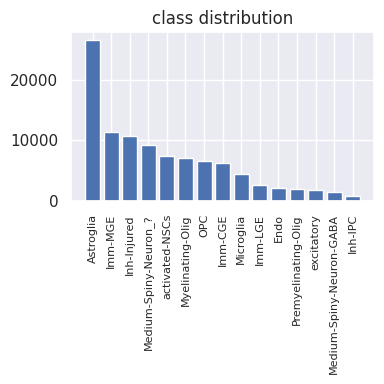


=== condition distribution ===
5d_HIE: 60633 (58.06%)
non-HIE: 25118 (24.05%)
2mo_HIE: 18687 (17.89%)


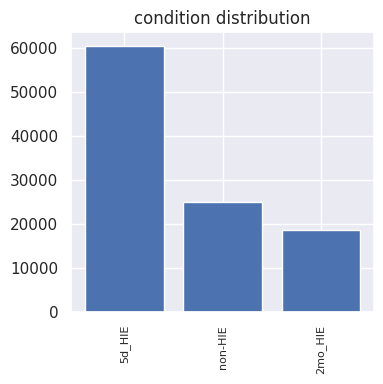


Example 'input_ids' length for row 0: 4096 (first 10): [2, 15927, 16559, 6428, 173, 16581, 11382, 5253, 17462, 11346]


In [3]:
from pathlib import Path
from collections import Counter
from datasets import load_from_disk, Dataset, DatasetDict, concatenate_datasets
import pandas as pd
import matplotlib.pyplot as plt

# --- Workdir + dataset path ---
WORKDIR = Path("/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_3_full_h5ad.reprocess.sep10.dataset")
DATASET_NAME = "hypoxia_all_samples_tokens.dataset"   

hypoxia_dataset = (WORKDIR / DATASET_NAME).resolve()
assert hypoxia_dataset.exists(), (
    f"Not found: {hypoxia_dataset}\n"
    f"Tip: available *.dataset dirs here: {[p.name for p in WORKDIR.glob('*.dataset')]}"
)

print("📁 WORKDIR:", WORKDIR)
print("📦 Dataset path:", hypoxia_dataset)

# --- Load ---
token_dataset = load_from_disk(str(hypoxia_dataset))

# Define ds_view (merge if DatasetDict)
if isinstance(token_dataset, DatasetDict):
    ds_view = concatenate_datasets(list(token_dataset.values()))
else:
    ds_view = token_dataset

# --- Basic info ---
print("Type of loaded dataset:", type(token_dataset))
print("Dataset summary:")
print(token_dataset)

# --- Features / schema ---
print("\nDataset features (schema):")
print(ds_view.features)

# --- Quick peek (first 2 records) ---
n_peek = min(2, len(ds_view))
print(f"\nFirst {n_peek} records:")
print(ds_view[:n_peek])

# --- Small pandas preview (safe) ---
HEAD_N = min(5, len(ds_view))
df_head = ds_view.select(range(HEAD_N)).to_pandas()
print("\nHead of the dataset as pandas DataFrame:")
print(df_head)

# Keep for later steps
original_dataset = token_dataset

# --- Optional: quick distributions if present ---
cols_to_check = ["class", "condition"]
for col in cols_to_check:
    if col in ds_view.column_names:
        c = Counter(ds_view[col])
        total = sum(c.values())
        print(f"\n=== {col} distribution ===")
        for k, v in c.most_common(15):
            print(f"{k}: {v} ({v/total*100:.2f}%)")

        # Small bar plot (top 15) — shown inline
        labels, values = zip(*c.most_common(15))
        plt.figure(figsize=(4, 4))
        plt.bar(range(len(values)), values)
        plt.xticks(range(len(values)), labels, rotation=90, fontsize=8)
        plt.title(f"{col} distribution")
        plt.tight_layout()
        plt.show()
    else:
        print(f"\nColumn '{col}' not found. Available: {ds_view.column_names}")

# --- Optional: input_ids shape sanity ---
if "input_ids" in ds_view.column_names and len(ds_view) > 0:
    ex0 = ds_view[0]["input_ids"]
    print(f"\nExample 'input_ids' length for row 0: {len(ex0)} (first 10): {ex0[:10]}")


Cells × Condition — COUNTS (original, limited to displayed classes)


condition,2mo_HIE,5d_HIE,non-HIE
class,,,
Astroglia,62,15704,10782
Imm-MGE,292,7677,3386
Inh-Injured,242,9562,885
Medium-Spiny-Neuron_?,799,8297,172
activated-NSCs,4618,1862,985
Myelinating-Olig,6090,347,607
OPC,1899,3117,1489
Imm-CGE,1117,3191,1895
Microglia,264,3064,1030



Cells × Condition — COLUMN % (within condition)


condition,2mo_HIE,5d_HIE,non-HIE
class,,,
Astroglia,0.33,25.92,42.96
Imm-MGE,1.56,12.67,13.49
Inh-Injured,1.30,15.78,3.53
Medium-Spiny-Neuron_?,4.28,13.70,0.69
activated-NSCs,24.71,3.07,3.93
Myelinating-Olig,32.59,0.57,2.42
OPC,10.16,5.15,5.93
Imm-CGE,5.98,5.27,7.55
Microglia,1.41,5.06,4.10


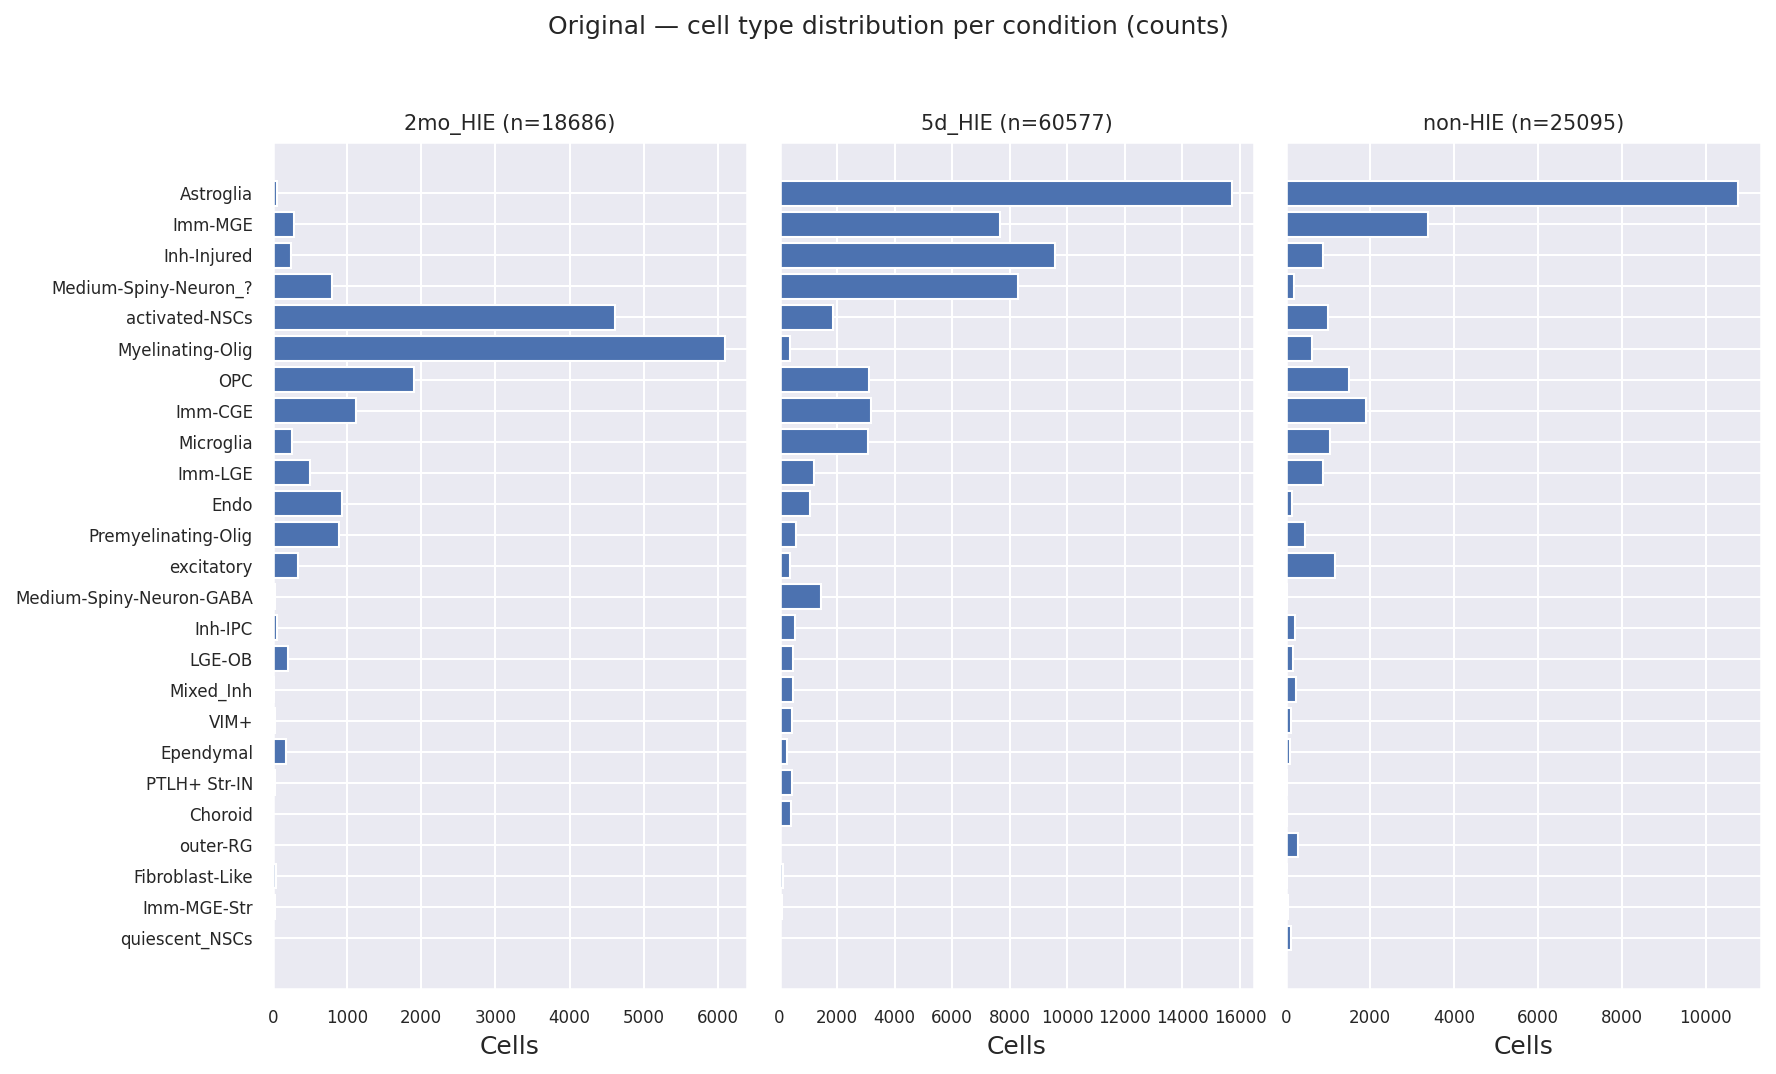

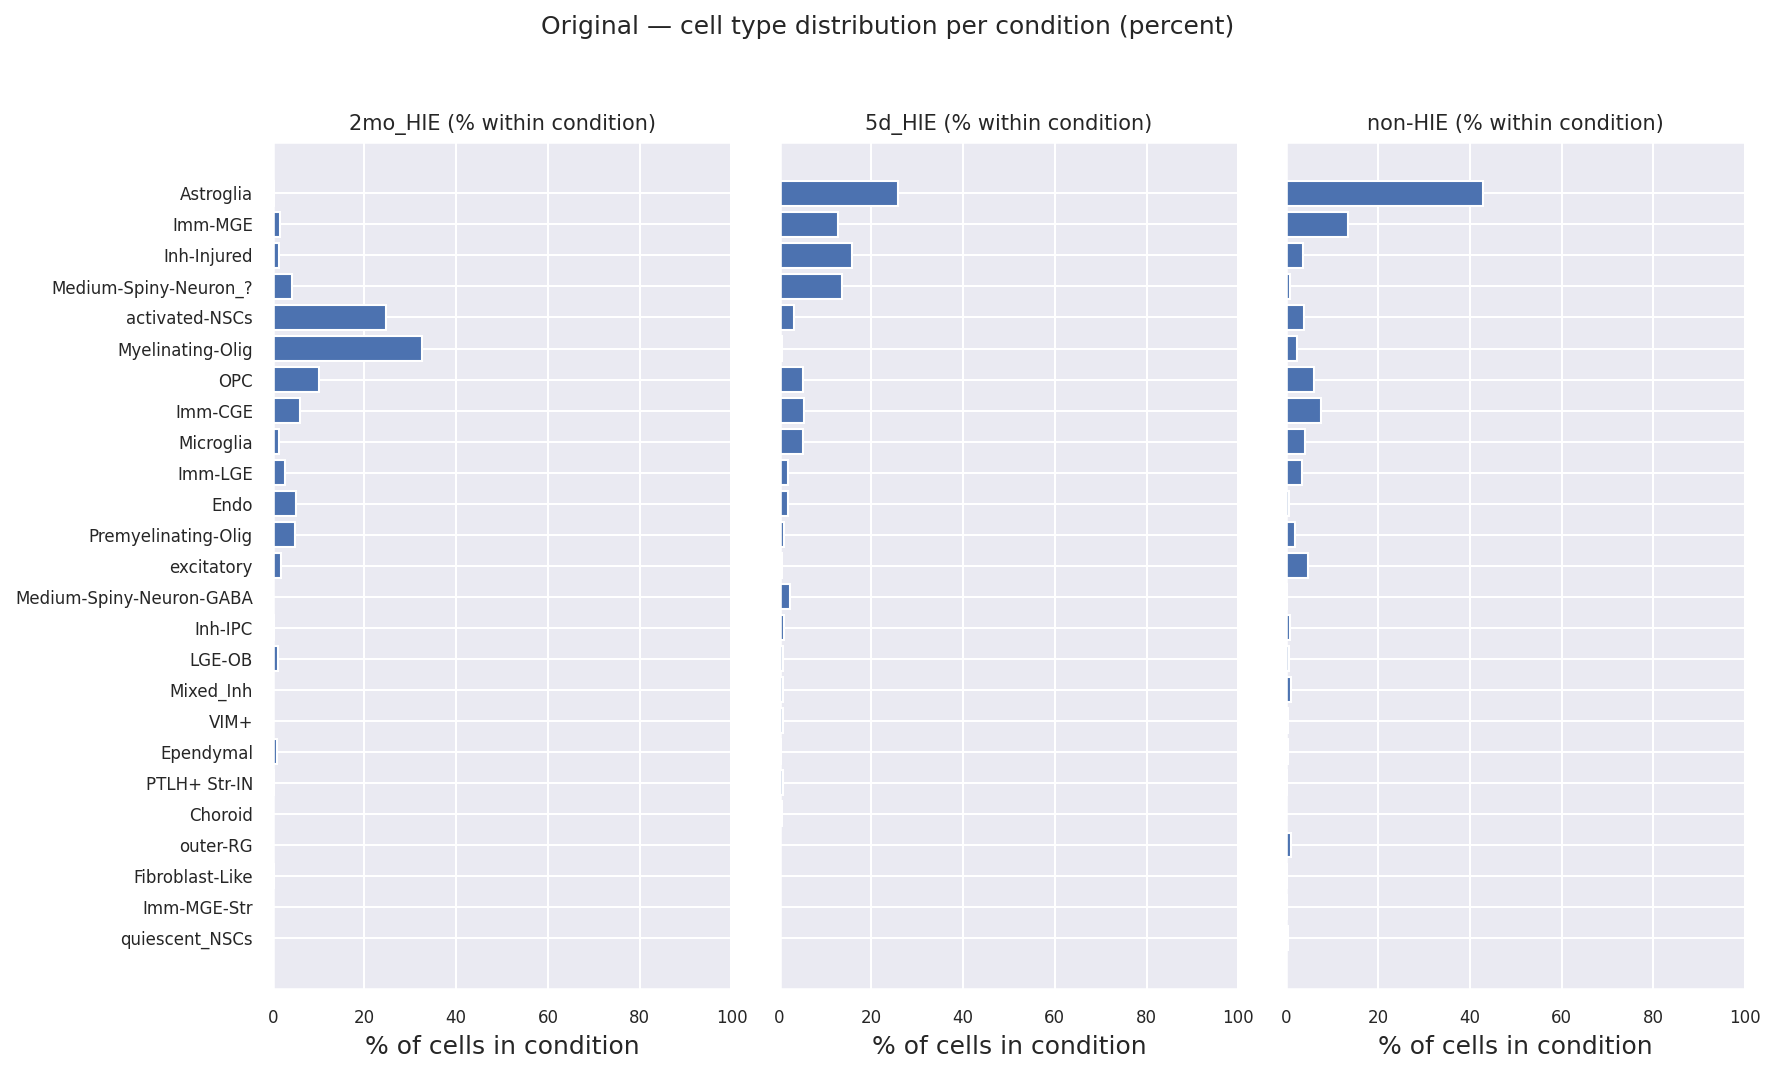

Saved figures to: original_per_condition/


In [4]:
# === Per-condition distributions for the ORIGINAL dataset `original_dataset` ===
from datasets import Dataset, DatasetDict, concatenate_datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# --- config ---
OUTDIR = "original_per_condition"
TOP_N  = 25        # limit to top-N classes overall for readability; set None for all
DPI    = 150
os.makedirs(OUTDIR, exist_ok=True)

# Normalize to a single Dataset
orig_ds = original_dataset
if isinstance(orig_ds, DatasetDict):
    orig_ds = concatenate_datasets(list(orig_ds.values()))
elif not isinstance(orig_ds, Dataset):
    raise TypeError(f"Unexpected type: {type(orig_ds)}")

# Build tidy DataFrame
df_orig = pd.DataFrame({"class": orig_ds["class"], "condition": orig_ds["condition"]})

# Counts: rows = class, cols = condition
counts = pd.crosstab(df_orig["class"], df_orig["condition"]).sort_index()
conditions = counts.columns.tolist()

# Choose a consistent class order (top-N by overall total)
if TOP_N is not None:
    class_order = counts.sum(axis=1).sort_values(ascending=False).head(TOP_N).index.tolist()
    counts = counts.loc[class_order]
else:
    class_order = counts.index.tolist()

# Column % (within each condition)
colpct = (counts.div(counts.sum(axis=0).replace(0, np.nan), axis=1) * 100.0).fillna(0.0).round(2)

# --- Print tables ---
from IPython.display import display
print("Cells × Condition — COUNTS (original, limited to displayed classes)")
display(counts)
print("\nCells × Condition — COLUMN % (within condition)")
display(colpct)

# --- Plot: per-condition barh (COUNTS) ---
n_cond  = len(conditions)
n_class = len(class_order)
fig_h   = max(6, 0.28 * n_class)

fig, axes = plt.subplots(1, n_cond, figsize=(4.0 * n_cond, fig_h), sharey=True, dpi=DPI)
if n_cond == 1:
    axes = [axes]

ypos = np.arange(n_class)
for ax, cond in zip(axes, conditions):
    vals = counts[cond].reindex(class_order).values
    ax.barh(ypos, vals)
    ax.set_title(f"{cond} (n={int(vals.sum())})", fontsize=10)
    ax.set_yticks(ypos)
    ax.set_yticklabels(class_order, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("Cells")
    ax.tick_params(axis="x", labelsize=8)

fig.suptitle("Original — cell type distribution per condition (counts)", fontsize=12, y=1.02)
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(OUTDIR, "per_condition_counts_barh.png"), dpi=DPI, bbox_inches="tight")
plt.close(fig)

# --- Plot: per-condition barh (COLUMN %) ---
fig, axes = plt.subplots(1, n_cond, figsize=(4.0 * n_cond, fig_h), sharey=True, dpi=DPI)
if n_cond == 1:
    axes = [axes]

for ax, cond in zip(axes, conditions):
    vals = colpct[cond].reindex(class_order).values
    ax.barh(ypos, vals)
    ax.set_title(f"{cond} (% within condition)", fontsize=10)
    ax.set_yticks(ypos)
    ax.set_yticklabels(class_order, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_xlabel("% of cells in condition")
    ax.tick_params(axis="x", labelsize=8)

fig.suptitle("Original — cell type distribution per condition (percent)", fontsize=12, y=1.02)
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(OUTDIR, "per_condition_colpct_barh.png"), dpi=DPI, bbox_inches="tight")
plt.close(fig)

print(f"Saved figures to: {OUTDIR}/")


In [5]:
print("Which cell types are in percentage higher than 5% ?")

Which cell types are in percentage higher than 5% ?


In [6]:
# === Per-condition distributions for the ORIGINAL dataset `original_dataset` ===
from datasets import Dataset, DatasetDict, concatenate_datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# --- config ---
OUTDIR = "original_per_condition"
TOP_N  = 25        # limit to top-N classes overall for readability; set None for all
DPI    = 150
MIN_PERCENTAGE = 5.0  # 5% threshold per condition
os.makedirs(OUTDIR, exist_ok=True)

# Normalize to a single Dataset
orig_ds = original_dataset
if isinstance(orig_ds, DatasetDict):
    orig_ds = concatenate_datasets(list(orig_ds.values()))
elif not isinstance(orig_ds, Dataset):
    raise TypeError(f"Unexpected type: {type(orig_ds)}")

# Build tidy DataFrame
df_orig = pd.DataFrame({"class": orig_ds["class"], "condition": orig_ds["condition"]})

# Counts: rows = class, cols = condition
counts = pd.crosstab(df_orig["class"], df_orig["condition"]).sort_index()
conditions = counts.columns.tolist()

# Choose a consistent class order (top-N by overall total)
if TOP_N is not None:
    class_order = counts.sum(axis=1).sort_values(ascending=False).head(TOP_N).index.tolist()
    counts = counts.loc[class_order]
else:
    class_order = counts.index.tolist()

# Column % (within each condition)
colpct = (counts.div(counts.sum(axis=0).replace(0, np.nan), axis=1) * 100.0).fillna(0.0).round(2)

# =============================================================================
# 5% THRESHOLD ANALYSIS
# =============================================================================
print("="*80)
print("5% THRESHOLD ANALYSIS PER CONDITION")
print("="*80)

# Check which cell types meet 5% threshold in each condition
meets_threshold = colpct >= MIN_PERCENTAGE

print(f"Cell types meeting {MIN_PERCENTAGE}% threshold in each condition:")
print("-" * 60)

for condition in conditions:
    condition_cell_types = meets_threshold[condition]
    qualifying_types = condition_cell_types[condition_cell_types].index.tolist()
    print(f"\n{condition}:")
    print(f"  Total cell types: {len(condition_cell_types)}")
    print(f"  Meeting {MIN_PERCENTAGE}% threshold: {len(qualifying_types)}")
    print(f"  Qualifying types: {qualifying_types}")
    
    # Show percentages for qualifying types
    for cell_type in qualifying_types:
        pct = colpct.loc[cell_type, condition]
        print(f"    - {cell_type}: {pct:.2f}%")

# Find cell types that meet 5% threshold in ALL conditions
print(f"\n" + "="*60)
print("CELL TYPES MEETING 5% THRESHOLD IN ALL CONDITIONS")
print("="*60)

all_conditions_meet = meets_threshold.all(axis=1)
qualifying_all_conditions = all_conditions_meet[all_conditions_meet].index.tolist()

print(f"Cell types meeting {MIN_PERCENTAGE}% in ALL conditions: {len(qualifying_all_conditions)}")
print(f"Qualifying types: {qualifying_all_conditions}")

# Show detailed breakdown for each qualifying type
print(f"\nDetailed breakdown for qualifying types:")
for cell_type in qualifying_all_conditions:
    print(f"\n{cell_type}:")
    for condition in conditions:
        pct = colpct.loc[cell_type, condition]
        status = "✓" if pct >= MIN_PERCENTAGE else "✗"
        print(f"  - {condition}: {pct:.2f}% {status}")

# Find cell types that meet 5% threshold in ANY condition
print(f"\n" + "="*60)
print("CELL TYPES MEETING 5% THRESHOLD IN ANY CONDITION")
print("="*60)

any_condition_meets = meets_threshold.any(axis=1)
qualifying_any_condition = any_condition_meets[any_condition_meets].index.tolist()

print(f"Cell types meeting {MIN_PERCENTAGE}% in ANY condition: {len(qualifying_any_condition)}")
print(f"Qualifying types: {qualifying_any_condition}")

# Show which conditions each type qualifies for
print(f"\nDetailed breakdown for any-condition qualifying types:")
for cell_type in qualifying_any_condition:
    print(f"\n{cell_type}:")
    qualifying_conditions = []
    for condition in conditions:
        pct = colpct.loc[cell_type, condition]
        if pct >= MIN_PERCENTAGE:
            qualifying_conditions.append(condition)
            print(f"  - {condition}: {pct:.2f}% ✓")
        else:
            print(f"  - {condition}: {pct:.2f}% ✗")
    print(f"  → Qualifies in: {qualifying_conditions}")

5% THRESHOLD ANALYSIS PER CONDITION
Cell types meeting 5.0% threshold in each condition:
------------------------------------------------------------

2mo_HIE:
  Total cell types: 25
  Meeting 5.0% threshold: 5
  Qualifying types: ['activated-NSCs', 'Myelinating-Olig', 'OPC', 'Imm-CGE', 'Endo']
    - activated-NSCs: 24.71%
    - Myelinating-Olig: 32.59%
    - OPC: 10.16%
    - Imm-CGE: 5.98%
    - Endo: 5.00%

5d_HIE:
  Total cell types: 25
  Meeting 5.0% threshold: 7
  Qualifying types: ['Astroglia', 'Imm-MGE', 'Inh-Injured', 'Medium-Spiny-Neuron_?', 'OPC', 'Imm-CGE', 'Microglia']
    - Astroglia: 25.92%
    - Imm-MGE: 12.67%
    - Inh-Injured: 15.78%
    - Medium-Spiny-Neuron_?: 13.70%
    - OPC: 5.15%
    - Imm-CGE: 5.27%
    - Microglia: 5.06%

non-HIE:
  Total cell types: 25
  Meeting 5.0% threshold: 4
  Qualifying types: ['Astroglia', 'Imm-MGE', 'OPC', 'Imm-CGE']
    - Astroglia: 42.96%
    - Imm-MGE: 13.49%
    - OPC: 5.93%
    - Imm-CGE: 7.55%

CELL TYPES MEETING 5% THRESHOLD I

In [7]:
print("Which cell types are in percentage higher than 1% ?")

Which cell types are in percentage higher than 1% ?


In [8]:
# === Per-condition distributions for the ORIGINAL dataset `original_dataset` ===
from datasets import Dataset, DatasetDict, concatenate_datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# --- config ---
OUTDIR = "original_per_condition"
TOP_N  = 25        # limit to top-N classes overall for readability; set None for all
DPI    = 150
MIN_PERCENTAGE = 1.0  # 1% threshold per condition
os.makedirs(OUTDIR, exist_ok=True)

# Normalize to a single Dataset
orig_ds = original_dataset
if isinstance(orig_ds, DatasetDict):
    orig_ds = concatenate_datasets(list(orig_ds.values()))
elif not isinstance(orig_ds, Dataset):
    raise TypeError(f"Unexpected type: {type(orig_ds)}")

# Build tidy DataFrame
df_orig = pd.DataFrame({"class": orig_ds["class"], "condition": orig_ds["condition"]})

# Counts: rows = class, cols = condition
counts = pd.crosstab(df_orig["class"], df_orig["condition"]).sort_index()
conditions = counts.columns.tolist()

# Choose a consistent class order (top-N by overall total)
if TOP_N is not None:
    class_order = counts.sum(axis=1).sort_values(ascending=False).head(TOP_N).index.tolist()
    counts = counts.loc[class_order]
else:
    class_order = counts.index.tolist()

# Column % (within each condition)
colpct = (counts.div(counts.sum(axis=0).replace(0, np.nan), axis=1) * 100.0).fillna(0.0).round(2)

# =============================================================================
# 1% THRESHOLD ANALYSIS
# =============================================================================
print("="*80)
print("1% THRESHOLD ANALYSIS PER CONDITION")
print("="*80)

# Check which cell types meet 1% threshold in each condition
meets_threshold = colpct >= MIN_PERCENTAGE

print(f"Cell types meeting {MIN_PERCENTAGE}% threshold in each condition:")
print("-" * 60)

for condition in conditions:
    condition_cell_types = meets_threshold[condition]
    qualifying_types = condition_cell_types[condition_cell_types].index.tolist()
    print(f"\n{condition}:")
    print(f"  Total cell types: {len(condition_cell_types)}")
    print(f"  Meeting {MIN_PERCENTAGE}% threshold: {len(qualifying_types)}")
    print(f"  Qualifying types: {qualifying_types}")
    
    # Show percentages for qualifying types
    for cell_type in qualifying_types:
        pct = colpct.loc[cell_type, condition]
        print(f"    - {cell_type}: {pct:.2f}%")

# Find cell types that meet 1% threshold in ALL conditions
print(f"\n" + "="*60)
print("CELL TYPES MEETING 1% THRESHOLD IN ALL CONDITIONS")
print("="*60)

all_conditions_meet = meets_threshold.all(axis=1)
qualifying_all_conditions = all_conditions_meet[all_conditions_meet].index.tolist()

print(f"Cell types meeting {MIN_PERCENTAGE}% in ALL conditions: {len(qualifying_all_conditions)}")
print(f"Qualifying types: {qualifying_all_conditions}")

# Show detailed breakdown for each qualifying type
print(f"\nDetailed breakdown for qualifying types:")
for cell_type in qualifying_all_conditions:
    print(f"\n{cell_type}:")
    for condition in conditions:
        pct = colpct.loc[cell_type, condition]
        status = "✓" if pct >= MIN_PERCENTAGE else "✗"
        print(f"  - {condition}: {pct:.2f}% {status}")

# Find cell types that meet 1% threshold in ANY condition
print(f"\n" + "="*60)
print("CELL TYPES MEETING 1% THRESHOLD IN ANY CONDITION")
print("="*60)

any_condition_meets = meets_threshold.any(axis=1)
qualifying_any_condition = any_condition_meets[any_condition_meets].index.tolist()

print(f"Cell types meeting {MIN_PERCENTAGE}% in ANY condition: {len(qualifying_any_condition)}")
print(f"Qualifying types: {qualifying_any_condition}")

# Show which conditions each type qualifies for
print(f"\nDetailed breakdown for any-condition qualifying types:")
for cell_type in qualifying_any_condition:
    print(f"\n{cell_type}:")
    qualifying_conditions = []
    for condition in conditions:
        pct = colpct.loc[cell_type, condition]
        if pct >= MIN_PERCENTAGE:
            qualifying_conditions.append(condition)
            print(f"  - {condition}: {pct:.2f}% ✓")
        else:
            print(f"  - {condition}: {pct:.2f}% ✗")
    print(f"  → Qualifies in: {qualifying_conditions}")

# Summary statistics
print(f"\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

total_cell_types = len(counts)
all_conditions_count = len(qualifying_all_conditions)
any_condition_count = len(qualifying_any_condition)

print(f"Total cell types in dataset: {total_cell_types}")
print(f"Cell types meeting {MIN_PERCENTAGE}% in ALL conditions: {all_conditions_count} ({all_conditions_count/total_cell_types*100:.1f}%)")
print(f"Cell types meeting {MIN_PERCENTAGE}% in ANY condition: {any_condition_count} ({any_condition_count/total_cell_types*100:.1f}%)")
print(f"Cell types NOT meeting {MIN_PERCENTAGE}% in ANY condition: {total_cell_types - any_condition_count} ({(total_cell_types - any_condition_count)/total_cell_types*100:.1f}%)")

# Comparison with 5% threshold
print(f"\n" + "="*60)
print("COMPARISON: 1% vs 5% THRESHOLD")
print("="*60)

# Calculate 5% threshold for comparison
meets_5pct = colpct >= 5.0
all_conditions_5pct = meets_5pct.all(axis=1)
qualifying_all_5pct = all_conditions_5pct[all_conditions_5pct].index.tolist()
any_condition_5pct = meets_5pct.any(axis=1)
qualifying_any_5pct = any_condition_5pct[any_condition_5pct].index.tolist()

print(f"5% threshold - ALL conditions: {len(qualifying_all_5pct)} cell types")
print(f"1% threshold - ALL conditions: {len(qualifying_all_conditions)} cell types")
print(f"Difference (1% vs 5%): +{len(qualifying_all_conditions) - len(qualifying_all_5pct)} cell types")

print(f"\n5% threshold - ANY condition: {len(qualifying_any_5pct)} cell types")
print(f"1% threshold - ANY condition: {len(qualifying_any_condition)} cell types")
print(f"Difference (1% vs 5%): +{len(qualifying_any_condition) - len(qualifying_any_5pct)} cell types")

# Show which cell types are gained by lowering threshold to 1%
gained_all_conditions = set(qualifying_all_conditions) - set(qualifying_all_5pct)
gained_any_condition = set(qualifying_any_condition) - set(qualifying_any_5pct)

if gained_all_conditions:
    print(f"\nCell types gained by lowering threshold to 1% (ALL conditions):")
    for cell_type in sorted(gained_all_conditions):
        print(f"  - {cell_type}")

if gained_any_condition:
    print(f"\nCell types gained by lowering threshold to 1% (ANY condition):")
    for cell_type in sorted(gained_any_condition):
        print(f"  - {cell_type}")



1% THRESHOLD ANALYSIS PER CONDITION
Cell types meeting 1.0% threshold in each condition:
------------------------------------------------------------

2mo_HIE:
  Total cell types: 25
  Meeting 1.0% threshold: 13
  Qualifying types: ['Imm-MGE', 'Inh-Injured', 'Medium-Spiny-Neuron_?', 'activated-NSCs', 'Myelinating-Olig', 'OPC', 'Imm-CGE', 'Microglia', 'Imm-LGE', 'Endo', 'Premyelinating-Olig', 'excitatory', 'LGE-OB']
    - Imm-MGE: 1.56%
    - Inh-Injured: 1.30%
    - Medium-Spiny-Neuron_?: 4.28%
    - activated-NSCs: 24.71%
    - Myelinating-Olig: 32.59%
    - OPC: 10.16%
    - Imm-CGE: 5.98%
    - Microglia: 1.41%
    - Imm-LGE: 2.67%
    - Endo: 5.00%
    - Premyelinating-Olig: 4.78%
    - excitatory: 1.81%
    - LGE-OB: 1.08%

5d_HIE:
  Total cell types: 25
  Meeting 1.0% threshold: 11
  Qualifying types: ['Astroglia', 'Imm-MGE', 'Inh-Injured', 'Medium-Spiny-Neuron_?', 'activated-NSCs', 'OPC', 'Imm-CGE', 'Microglia', 'Imm-LGE', 'Endo', 'Medium-Spiny-Neuron-GABA']
    - Astroglia: 25.

In [9]:
print("""
Types of Stratification:

1. Single Stratification:
   One variable (e.g., cell type only)
   Simple proportional sampling
   Example: Sample 10% from each cell type

2. Joint Stratification:
   Multiple variables (e.g., cell type + condition)
   Preserves interactions between variables
   Example: Sample proportionally from each cell type within each condition

3. Balanced Stratification:
   Equal representation across groups
   Ignores original proportions
   Example: 100 cells from each cell type regardless of original frequency
""")



Types of Stratification:

1. Single Stratification:
   One variable (e.g., cell type only)
   Simple proportional sampling
   Example: Sample 10% from each cell type

2. Joint Stratification:
   Multiple variables (e.g., cell type + condition)
   Preserves interactions between variables
   Example: Sample proportionally from each cell type within each condition

3. Balanced Stratification:
   Equal representation across groups
   Ignores original proportions
   Example: 100 cells from each cell type regardless of original frequency



In [12]:
# =============================================================================
# STRATIFIED SUBSAMPLING: 9000 CELLS TOTAL
# =============================================================================

from datasets import Dataset, DatasetDict, concatenate_datasets
from collections import defaultdict, Counter
import pandas as pd
import numpy as np
import math, random, os, shutil

# ========= CONFIG =========
TARGET_N   = 9000          # total cells after downsampling
RARE_FRAC  = 0.05          # drop classes <5% of ORIGINAL dataset
SEED       = 42
SAVE_PATH  = "./hypoxia_all_samples_9000_in_total.dataset"  # Fixed: removed undefined variable
NUM_PROC   = 8
# ==========================

print("="*80)
print("STRATIFIED SUBSAMPLING: 9000 CELLS TOTAL")
print("="*80)
print(f"Target: {TARGET_N:,} total cells")
print(f"Rare class threshold: {RARE_FRAC*100}%")

# 0) Normalize to a single Dataset
ds = original_dataset
if isinstance(ds, DatasetDict):
    ds = concatenate_datasets(list(ds.values()))
elif not isinstance(ds, Dataset):
    raise TypeError(f"Unexpected type: {type(ds)}")

# 1) Sanity checks
for col in ["class", "condition"]:
    if col not in ds.column_names:
        raise KeyError(f"Missing column '{col}'. Available: {ds.column_names}")

print(f"Start: {len(ds):,} cells")

# 2) Drop classes occurring in <5% of ORIGINAL dataset
total0 = len(ds)
class_counts0 = Counter(ds["class"])
keep_classes = [k for k, v in class_counts0.items() if v / total0 >= RARE_FRAC]
ds = ds.filter(lambda ex, keep=keep_classes: ex["class"] in keep, num_proc=NUM_PROC)
print(f"After 5% class filter → {len(ds):,} cells; kept {len(keep_classes)} classes")

# 3) If no downsampling needed, just shuffle
if TARGET_N >= len(ds):
    ds_down = ds.shuffle(seed=SEED)
    print("TARGET_N ≥ filtered size; skipping downsampling (shuffled only).")
else:
    # --- joint (class||condition) quotas via largest remainder (Hamilton) ---
    joint_keys   = [f"{c}||{k}" for c, k in zip(ds["class"], ds["condition"])]
    joint_counts = Counter(joint_keys)
    total        = sum(joint_counts.values())

    exact = {k: TARGET_N * (v / total) for k, v in joint_counts.items()}
    base  = {k: int(math.floor(x)) for k, x in exact.items()}
    used  = sum(base.values())
    # distribute leftover by largest fractional parts
    remainder = sorted(((exact[k] - base[k], k) for k in base), reverse=True)
    for i in range(TARGET_N - used):
        _, k = remainder[i]
        base[k] += 1

    # sample per joint bucket
    parts = []
    for key, q in base.items():
        if q <= 0: 
            continue
        cls, cond = key.split("||", 1)
        sub = ds.filter(lambda ex, a=cls, b=cond: (ex["class"] == a) and (ex["condition"] == b),
                        num_proc=NUM_PROC)
        q = min(q, len(sub))
        if q > 0:
            parts.append(sub.shuffle(seed=SEED).select(range(q)))

    ds_down = concatenate_datasets(parts).shuffle(seed=SEED)

print(f"Downsampled size: {len(ds_down):,} (target={TARGET_N})")

# 4) Quick tables (counts & row-%)
df = pd.DataFrame({"class": ds_down["class"], "condition": ds_down["condition"]})
ct_counts  = pd.crosstab(df["class"], df["condition"]).sort_index()
ct_rowpct  = (ct_counts.div(ct_counts.sum(axis=1).replace(0, np.nan), axis=0) * 100).fillna(0).round(2)

print("\nCells × Condition — COUNTS (downsampled)")
print(ct_counts)  # Fixed: replaced display() with print()
print("\nCells × Condition — ROW % within class (downsampled)")
print(ct_rowpct)  # Fixed: replaced display() with print()

# 5) Save
if SAVE_PATH:
    if os.path.exists(SAVE_PATH):
        shutil.rmtree(SAVE_PATH)
    ds_down.save_to_disk(SAVE_PATH)
    print(f"\n✅ Saved downsampled dataset to: {SAVE_PATH}")

STRATIFIED SUBSAMPLING: 9000 CELLS TOTAL
Target: 9,000 total cells
Rare class threshold: 5.0%
Start: 104,438 cells
After 5% class filter → 85,077 cells; kept 8 classes
Downsampled size: 9,000 (target=9000)

Cells × Condition — COUNTS (downsampled)
condition              2mo_HIE  5d_HIE  non-HIE
class                                          
Astroglia                    7    1661     1141
Imm-CGE                    118     338      200
Imm-MGE                     31     812      358
Inh-Injured                 26    1012       94
Medium-Spiny-Neuron_?       84     878       18
Myelinating-Olig           644      37       64
OPC                        201     330      157
activated-NSCs             488     197      104

Cells × Condition — ROW % within class (downsampled)
condition              2mo_HIE  5d_HIE  non-HIE
class                                          
Astroglia                 0.25   59.13    40.62
Imm-CGE                  17.99   51.52    30.49
Imm-MGE                   

In [11]:
# =============================================================================
# COMPARISON: BEFORE vs AFTER STRATIFIED SUBSAMPLING
# =============================================================================

print(f"\n" + "="*80)
print("COMPARISON: BEFORE vs AFTER STRATIFIED SUBSAMPLING")
print("="*80)

# Create comparison tables
comparison_data = []

# Get conditions from original dataset
df_temp_orig = pd.DataFrame({"condition": ds["condition"]})
conditions = sorted(df_temp_orig["condition"].unique())

for condition in conditions:
    print(f"\n{'='*60}")
    print(f"CONDITION: {condition}")
    print(f"{'='*60}")
    
    # Original data for this condition (before any filtering)
    orig_condition = original_dataset
    if isinstance(orig_condition, DatasetDict):
        orig_condition = concatenate_datasets(list(orig_condition.values()))
    
    orig_condition = orig_condition.filter(lambda ex, cond=condition: ex["condition"] == cond, num_proc=NUM_PROC)
    orig_df = pd.DataFrame({"class": orig_condition["class"], "condition": orig_condition["condition"]})
    orig_crosstab = pd.crosstab(orig_df["class"], orig_df["condition"])
    orig_percentages = (orig_crosstab / orig_crosstab.sum(axis=0)) * 100
    orig_pct = orig_percentages[condition].to_dict()
    
    # Sampled data for this condition (after stratified subsampling)
    sampled_condition = ds_down.filter(lambda ex, cond=condition: ex["condition"] == cond, num_proc=NUM_PROC)
    sampled_df = pd.DataFrame({"class": sampled_condition["class"], "condition": sampled_condition["condition"]})
    sampled_crosstab = pd.crosstab(sampled_df["class"], sampled_df["condition"])
    sampled_percentages = (sampled_crosstab / sampled_crosstab.sum(axis=0)) * 100
    sampled_pct = sampled_percentages[condition].to_dict()
    
    # Get all unique cell types
    all_cell_types = set(orig_pct.keys()) | set(sampled_pct.keys())
    
    print(f"\nOriginal dataset: {len(orig_condition):,} cells")
    print(f"Sampled dataset: {len(sampled_condition):,} cells")
    print(f"Reduction: {((len(orig_condition) - len(sampled_condition)) / len(orig_condition) * 100):.1f}%")
    
    print(f"\n{'Cell Type':<25} {'Original %':<12} {'Sampled %':<12} {'Difference':<12} {'Status':<10}")
    print("-" * 80)
    
    for cell_type in sorted(all_cell_types):
        orig_val = orig_pct.get(cell_type, 0)
        sampled_val = sampled_pct.get(cell_type, 0)
        difference = sampled_val - orig_val
        
        # Determine status
        if abs(difference) < 0.5:
            status = "✓ Good"
        elif abs(difference) < 1.0:
            status = "⚠ Fair"
        else:
            status = "✗ Poor"
        
        print(f"{cell_type:<25} {orig_val:>10.2f}% {sampled_val:>10.2f}% {difference:>+10.2f}% {status:<10}")
        
        # Store for summary
        comparison_data.append({
            'condition': condition,
            'cell_type': cell_type,
            'original_pct': orig_val,
            'sampled_pct': sampled_val,
            'difference': difference,
            'status': status
        })

# Create summary DataFrame
comparison_df = pd.DataFrame(comparison_data)

print(f"\n{'='*80}")
print("SUMMARY STATISTICS")
print(f"{'='*80}")

# Overall statistics
print(f"\nOverall dataset sizes:")
print(f"  Original: {len(original_dataset):,} cells")
print(f"  Sampled: {len(ds_down):,} cells")
print(f"  Reduction: {((len(original_dataset) - len(ds_down)) / len(original_dataset) * 100):.1f}%")

# Distribution quality metrics
print(f"\nDistribution quality metrics:")
for condition in conditions:
    condition_data = comparison_df[comparison_df['condition'] == condition]
    
    # Calculate metrics
    mean_abs_diff = condition_data['difference'].abs().mean()
    max_abs_diff = condition_data['difference'].abs().max()
    good_count = (condition_data['difference'].abs() < 0.5).sum()
    total_count = len(condition_data)
    good_pct = (good_count / total_count) * 100
    
    print(f"\n{condition}:")
    print(f"  Mean absolute difference: {mean_abs_diff:.2f}%")
    print(f"  Max absolute difference: {max_abs_diff:.2f}%")
    print(f"  Well-preserved cell types: {good_count}/{total_count} ({good_pct:.1f}%)")

# Save comparison to CSV
comparison_df.to_csv("stratified_subsampling_comparison.csv", index=False)
print(f"\n✅ Comparison data saved to: stratified_subsampling_comparison.csv")

# Create a summary table
print(f"\n{'='*80}")
print("SUMMARY TABLE: CELL TYPE PERCENTAGES")
print(f"{'='*80}")

summary_table = comparison_df.pivot_table(
    index='cell_type', 
    columns='condition', 
    values=['original_pct', 'sampled_pct'], 
    fill_value=0
)

print(summary_table)

# Save summary table
summary_table.to_csv("stratified_subsampling_summary_table.csv")
print(f"\n✅ Summary table saved to: stratified_subsampling_summary_table.csv")

# Show cross-tabulation comparison
print(f"\n{'='*80}")
print("CROSS-TABULATION COMPARISON")
print(f"{'='*80}")

# Original cross-tabulation
print(f"\nORIGINAL DATASET:")
orig_df_all = pd.DataFrame({"class": original_dataset["class"], "condition": original_dataset["condition"]})
orig_ct_counts = pd.crosstab(orig_df_all["class"], orig_df_all["condition"]).sort_index()
orig_ct_rowpct = (orig_ct_counts.div(orig_ct_counts.sum(axis=1).replace(0, np.nan), axis=0) * 100).fillna(0).round(2)

print("Counts:")
print(orig_ct_counts)
print("\nRow percentages:")
print(orig_ct_rowpct)

# Sampled cross-tabulation
print(f"\nSTRATIFIED SUBSAMPLED DATASET:")
sampled_df_all = pd.DataFrame({"class": ds_down["class"], "condition": ds_down["condition"]})
sampled_ct_counts = pd.crosstab(sampled_df_all["class"], sampled_df_all["condition"]).sort_index()
sampled_ct_rowpct = (sampled_ct_counts.div(sampled_ct_counts.sum(axis=1).replace(0, np.nan), axis=0) * 100).fillna(0).round(2)

print("Counts:")
print(sampled_ct_counts)
print("\nRow percentages:")
print(sampled_ct_rowpct)

print(f"\n" + "="*60)
print("STRATIFIED SUBSAMPLING COMPLETE")
print("="*60)


COMPARISON: BEFORE vs AFTER STRATIFIED SUBSAMPLING

CONDITION: 2mo_HIE

Original dataset: 18,687 cells
Sampled dataset: 1,599 cells
Reduction: 91.4%

Cell Type                 Original %   Sampled %    Difference   Status    
--------------------------------------------------------------------------------
Astroglia                       0.33%       0.44%      +0.11% ✓ Good    
Choroid                         0.02%       0.00%      -0.02% ✓ Good    
Endo                            5.00%       0.00%      -5.00% ✗ Poor    
Ependymal                       0.93%       0.00%      -0.93% ⚠ Fair    
Fibroblast-Like                 0.25%       0.00%      -0.25% ✓ Good    
Imm-CGE                         5.98%       7.38%      +1.40% ✗ Poor    
Imm-LGE                         2.66%       0.00%      -2.66% ✗ Poor    
Imm-MGE                         1.56%       1.94%      +0.38% ✓ Good    
Imm-MGE-Str                     0.18%       0.00%      -0.18% ✓ Good    
Inh-IPC                         0.3

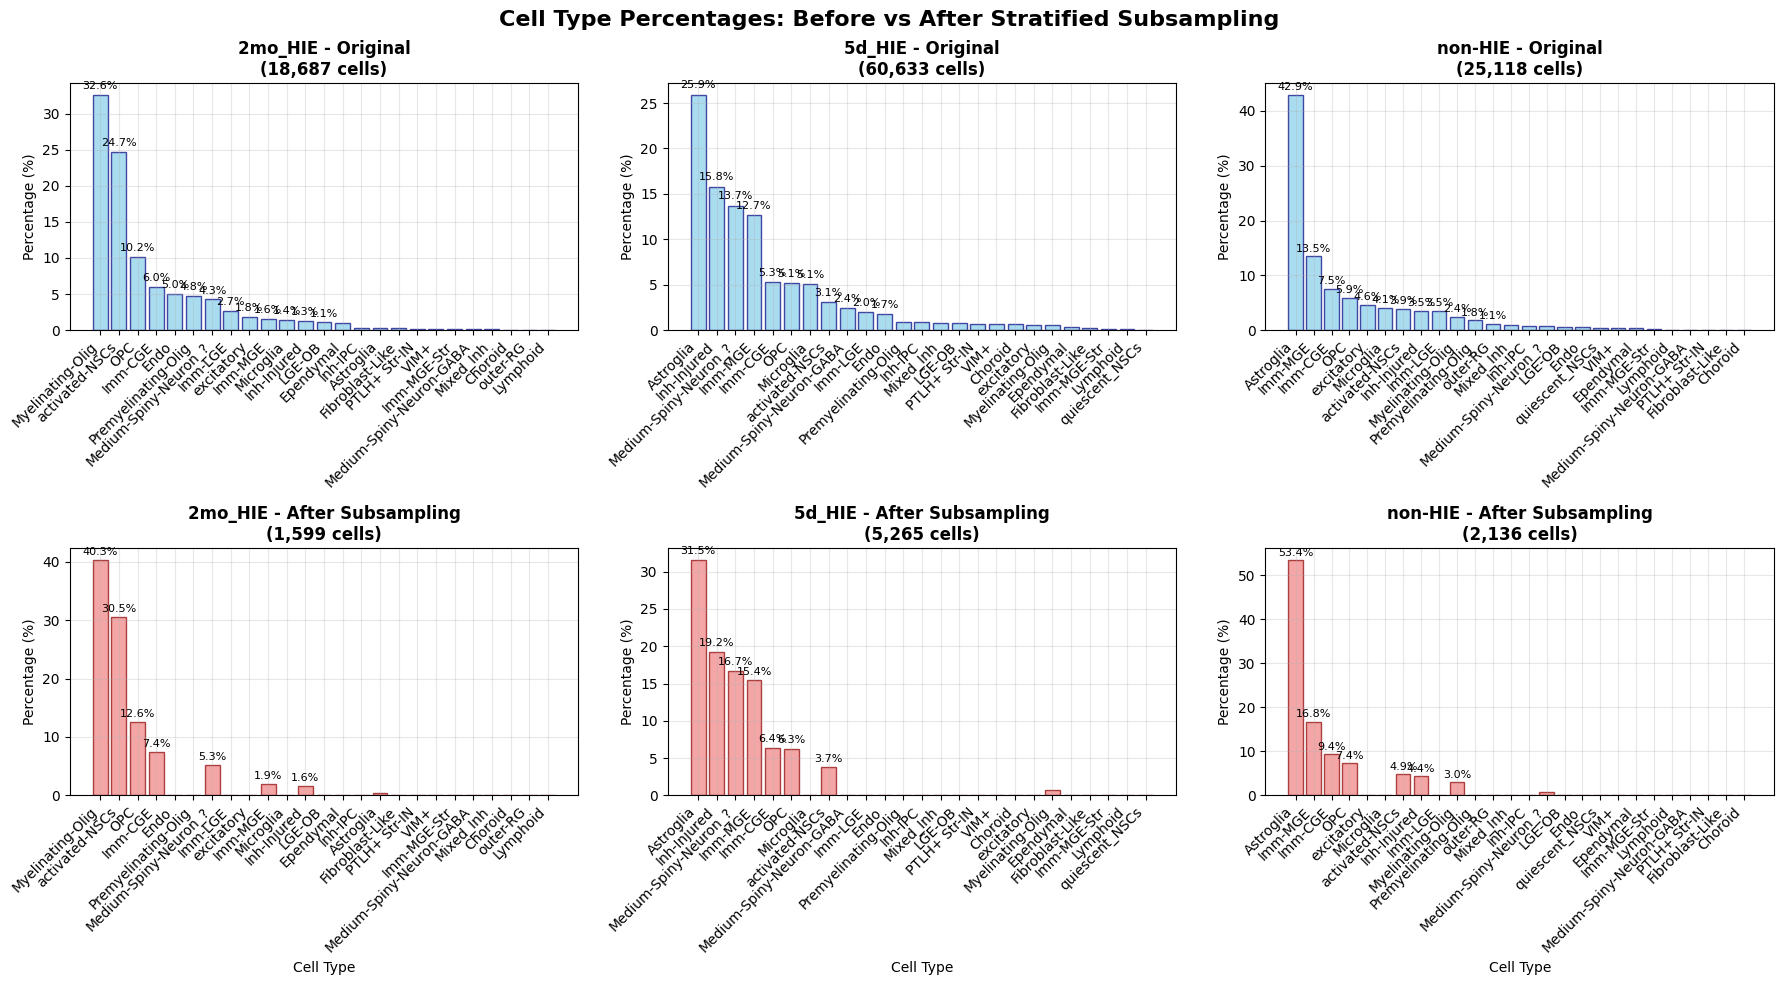

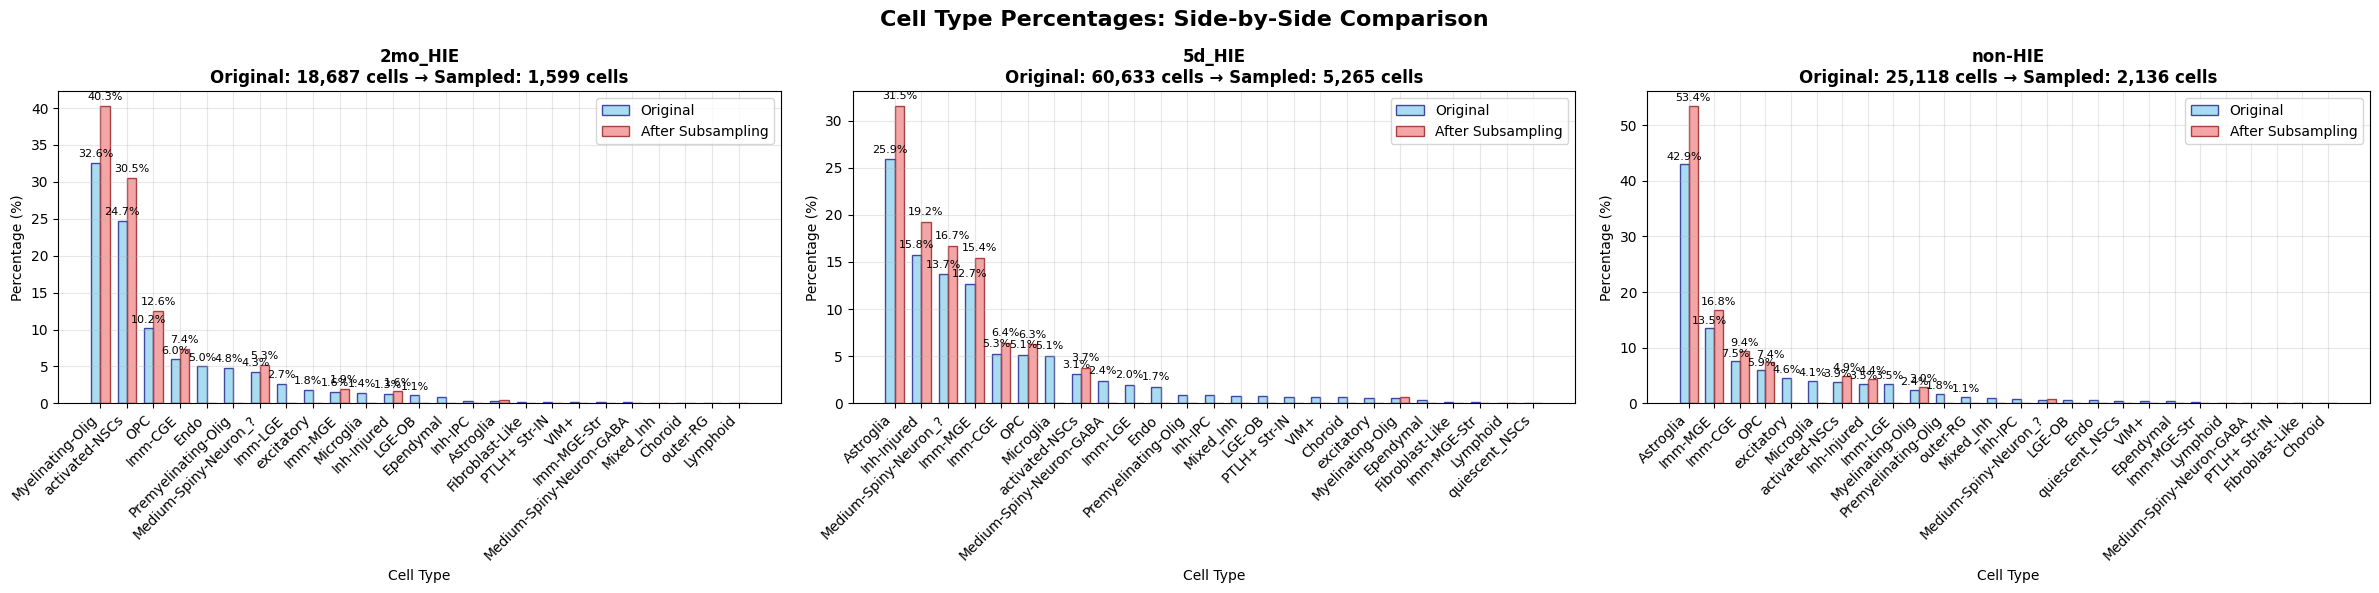

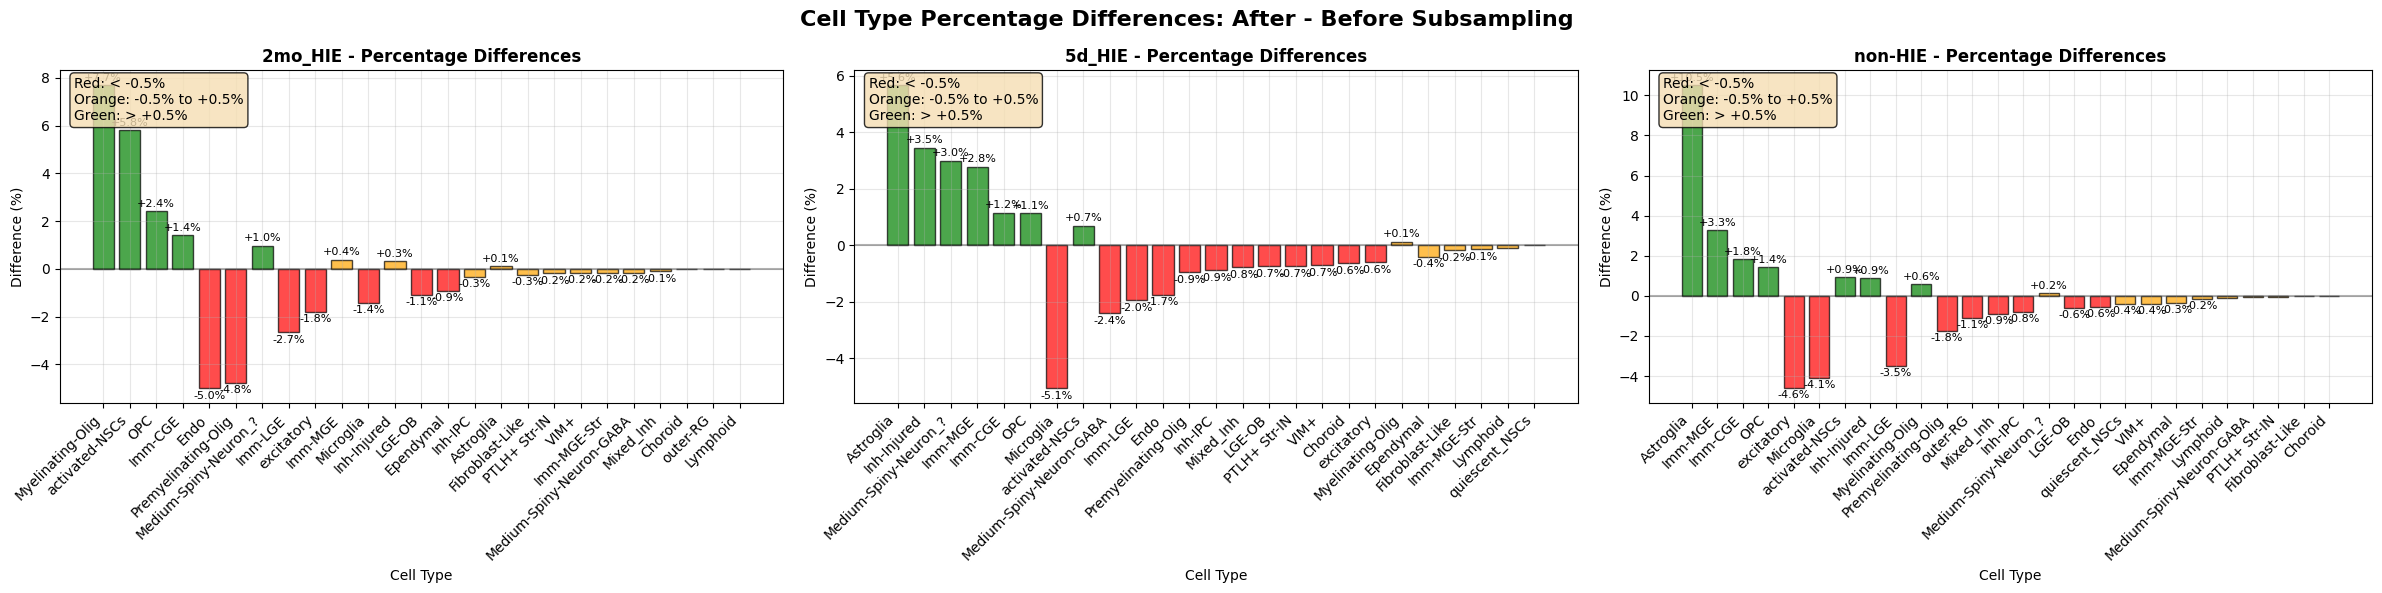

✅ Barplots saved:
  - stratified_subsampling_barplots.png
  - stratified_subsampling_side_by_side.png
  - stratified_subsampling_differences.png


In [13]:
# =============================================================================
# BARPLOTS: BEFORE vs AFTER STRATIFIED SUBSAMPLING
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('default')
sns.set_palette("husl")

# Create comparison plots
fig, axes = plt.subplots(2, len(conditions), figsize=(6*len(conditions), 10))
if len(conditions) == 1:
    axes = axes.reshape(2, 1)

fig.suptitle('Cell Type Percentages: Before vs After Stratified Subsampling', fontsize=16, fontweight='bold')

for i, condition in enumerate(conditions):
    # Get data for this condition
    orig_condition = original_dataset
    if isinstance(orig_condition, DatasetDict):
        orig_condition = concatenate_datasets(list(orig_condition.values()))
    
    orig_condition = orig_condition.filter(lambda ex, cond=condition: ex["condition"] == cond, num_proc=NUM_PROC)
    sampled_condition = ds_down.filter(lambda ex, cond=condition: ex["condition"] == cond, num_proc=NUM_PROC)
    
    # Calculate percentages
    orig_df = pd.DataFrame({"class": orig_condition["class"], "condition": orig_condition["condition"]})
    orig_crosstab = pd.crosstab(orig_df["class"], orig_df["condition"])
    orig_percentages = (orig_crosstab / orig_crosstab.sum(axis=0)) * 100
    orig_pct = orig_percentages[condition].to_dict()
    
    sampled_df = pd.DataFrame({"class": sampled_condition["class"], "condition": sampled_condition["condition"]})
    sampled_crosstab = pd.crosstab(sampled_df["class"], sampled_df["condition"])
    sampled_percentages = (sampled_crosstab / sampled_crosstab.sum(axis=0)) * 100
    sampled_pct = sampled_percentages[condition].to_dict()
    
    # Get all cell types and sort by original percentage
    all_cell_types = sorted(set(orig_pct.keys()) | set(sampled_pct.keys()), 
                           key=lambda x: orig_pct.get(x, 0), reverse=True)
    
    # Prepare data for plotting
    orig_values = [orig_pct.get(ct, 0) for ct in all_cell_types]
    sampled_values = [sampled_pct.get(ct, 0) for ct in all_cell_types]
    
    # Plot 1: Original percentages
    axes[0, i].bar(range(len(all_cell_types)), orig_values, alpha=0.7, color='skyblue', edgecolor='navy')
    axes[0, i].set_title(f'{condition} - Original\n({len(orig_condition):,} cells)', fontweight='bold')
    axes[0, i].set_ylabel('Percentage (%)')
    axes[0, i].set_xticks(range(len(all_cell_types)))
    axes[0, i].set_xticklabels(all_cell_types, rotation=45, ha='right')
    axes[0, i].grid(True, alpha=0.3)
    
    # Add value labels on bars
    for j, v in enumerate(orig_values):
        if v > 1:  # Only label bars > 1%
            axes[0, i].text(j, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)
    
    # Plot 2: Sampled percentages
    axes[1, i].bar(range(len(all_cell_types)), sampled_values, alpha=0.7, color='lightcoral', edgecolor='darkred')
    axes[1, i].set_title(f'{condition} - After Subsampling\n({len(sampled_condition):,} cells)', fontweight='bold')
    axes[1, i].set_ylabel('Percentage (%)')
    axes[1, i].set_xlabel('Cell Type')
    axes[1, i].set_xticks(range(len(all_cell_types)))
    axes[1, i].set_xticklabels(all_cell_types, rotation=45, ha='right')
    axes[1, i].grid(True, alpha=0.3)
    
    # Add value labels on bars
    for j, v in enumerate(sampled_values):
        if v > 1:  # Only label bars > 1%
            axes[1, i].text(j, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('stratified_subsampling_barplots.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# SIDE-BY-SIDE COMPARISON BARPLOTS
# =============================================================================

# Create side-by-side comparison plots
fig, axes = plt.subplots(1, len(conditions), figsize=(8*len(conditions), 6))
if len(conditions) == 1:
    axes = [axes]

fig.suptitle('Cell Type Percentages: Side-by-Side Comparison', fontsize=16, fontweight='bold')

for i, condition in enumerate(conditions):
    # Get data for this condition
    orig_condition = original_dataset
    if isinstance(orig_condition, DatasetDict):
        orig_condition = concatenate_datasets(list(orig_condition.values()))
    
    orig_condition = orig_condition.filter(lambda ex, cond=condition: ex["condition"] == cond, num_proc=NUM_PROC)
    sampled_condition = ds_down.filter(lambda ex, cond=condition: ex["condition"] == cond, num_proc=NUM_PROC)
    
    # Calculate percentages
    orig_df = pd.DataFrame({"class": orig_condition["class"], "condition": orig_condition["condition"]})
    orig_crosstab = pd.crosstab(orig_df["class"], orig_df["condition"])
    orig_percentages = (orig_crosstab / orig_crosstab.sum(axis=0)) * 100
    orig_pct = orig_percentages[condition].to_dict()
    
    sampled_df = pd.DataFrame({"class": sampled_condition["class"], "condition": sampled_condition["condition"]})
    sampled_crosstab = pd.crosstab(sampled_df["class"], sampled_df["condition"])
    sampled_percentages = (sampled_crosstab / sampled_crosstab.sum(axis=0)) * 100
    sampled_pct = sampled_percentages[condition].to_dict()
    
    # Get all cell types and sort by original percentage
    all_cell_types = sorted(set(orig_pct.keys()) | set(sampled_pct.keys()), 
                           key=lambda x: orig_pct.get(x, 0), reverse=True)
    
    # Prepare data for plotting
    orig_values = [orig_pct.get(ct, 0) for ct in all_cell_types]
    sampled_values = [sampled_pct.get(ct, 0) for ct in all_cell_types]
    
    # Create side-by-side bars
    x = np.arange(len(all_cell_types))
    width = 0.35
    
    bars1 = axes[i].bar(x - width/2, orig_values, width, label='Original', alpha=0.7, color='skyblue', edgecolor='navy')
    bars2 = axes[i].bar(x + width/2, sampled_values, width, label='After Subsampling', alpha=0.7, color='lightcoral', edgecolor='darkred')
    
    axes[i].set_title(f'{condition}\nOriginal: {len(orig_condition):,} cells → Sampled: {len(sampled_condition):,} cells', fontweight='bold')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_xlabel('Cell Type')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_cell_types, rotation=45, ha='right')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    
    # Add value labels on bars
    for j, (v1, v2) in enumerate(zip(orig_values, sampled_values)):
        if v1 > 1:  # Only label bars > 1%
            axes[i].text(j - width/2, v1 + 0.5, f'{v1:.1f}%', ha='center', va='bottom', fontsize=8)
        if v2 > 1:
            axes[i].text(j + width/2, v2 + 0.5, f'{v2:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('stratified_subsampling_side_by_side.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# DIFFERENCE BARPLOT
# =============================================================================

# Create difference plot
fig, axes = plt.subplots(1, len(conditions), figsize=(8*len(conditions), 6))
if len(conditions) == 1:
    axes = [axes]

fig.suptitle('Cell Type Percentage Differences: After - Before Subsampling', fontsize=16, fontweight='bold')

for i, condition in enumerate(conditions):
    # Get data for this condition
    orig_condition = original_dataset
    if isinstance(orig_condition, DatasetDict):
        orig_condition = concatenate_datasets(list(orig_condition.values()))
    
    orig_condition = orig_condition.filter(lambda ex, cond=condition: ex["condition"] == cond, num_proc=NUM_PROC)
    sampled_condition = ds_down.filter(lambda ex, cond=condition: ex["condition"] == cond, num_proc=NUM_PROC)
    
    # Calculate percentages
    orig_df = pd.DataFrame({"class": orig_condition["class"], "condition": orig_condition["condition"]})
    orig_crosstab = pd.crosstab(orig_df["class"], orig_df["condition"])
    orig_percentages = (orig_crosstab / orig_crosstab.sum(axis=0)) * 100
    orig_pct = orig_percentages[condition].to_dict()
    
    sampled_df = pd.DataFrame({"class": sampled_condition["class"], "condition": sampled_condition["condition"]})
    sampled_crosstab = pd.crosstab(sampled_df["class"], sampled_df["condition"])
    sampled_percentages = (sampled_crosstab / sampled_crosstab.sum(axis=0)) * 100
    sampled_pct = sampled_percentages[condition].to_dict()
    
    # Get all cell types and sort by original percentage
    all_cell_types = sorted(set(orig_pct.keys()) | set(sampled_pct.keys()), 
                           key=lambda x: orig_pct.get(x, 0), reverse=True)
    
    # Calculate differences
    differences = [sampled_pct.get(ct, 0) - orig_pct.get(ct, 0) for ct in all_cell_types]
    
    # Color bars based on difference
    colors = ['red' if d < -0.5 else 'orange' if d < 0.5 else 'green' for d in differences]
    
    bars = axes[i].bar(range(len(all_cell_types)), differences, color=colors, alpha=0.7, edgecolor='black')
    axes[i].set_title(f'{condition} - Percentage Differences', fontweight='bold')
    axes[i].set_ylabel('Difference (%)')
    axes[i].set_xlabel('Cell Type')
    axes[i].set_xticks(range(len(all_cell_types)))
    axes[i].set_xticklabels(all_cell_types, rotation=45, ha='right')
    axes[i].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    axes[i].grid(True, alpha=0.3)
    
    # Add value labels on bars
    for j, v in enumerate(differences):
        if abs(v) > 0.1:  # Only label significant differences
            axes[i].text(j, v + (0.1 if v >= 0 else -0.1), f'{v:+.1f}%', ha='center', va='bottom' if v >= 0 else 'top', fontsize=8)
    
    # Add legend
    axes[i].text(0.02, 0.98, 'Red: < -0.5%\nOrange: -0.5% to +0.5%\nGreen: > +0.5%', 
                transform=axes[i].transAxes, verticalalignment='top', 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('stratified_subsampling_differences.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Barplots saved:")
print("  - stratified_subsampling_barplots.png")
print("  - stratified_subsampling_side_by_side.png") 
print("  - stratified_subsampling_differences.png")

In [14]:
# Row % within class
# What it answers: “Within this cell class, how are its cells split across conditions?”

# Column % within condition
# What it answers: “Within this condition, how are its cells split across classes?”

# Condition-only stratification: you down-sample by columns (conditions) only. Column proportions are preserved; row/class proportions may shift.
# Class-only stratification: you down-sample by rows (classes) only. Row proportions are preserved; column/condition proportions may shift.
# Joint (class × condition) stratification (what we implemented): you down-sample by cells of the contingency table (each class–condition pair). 
# This effectively preserves both row and column distributions (marginals) as a consequence of preserving the joint distribution—allowing 
# for tiny rounding differences and any buckets with too few cells (which can end up at 0 after downsampling)

In [ ]:
# the results are in the folder : 
# test_geneformer_3_full_h5ad.reprocess.sep10.stratified.sampling.9000.dataset/